In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import griddata
auev=27.2114
cau=137.036
nnm=18.8973


In [2]:
########### PART I ###########

In [3]:
def rs(x,eps):
    im=1j*1e-10*0 #small imaginary part to avoid singularities (not necessary)
    return ((1-x**2+im)**0.5-(eps-x**2+im)**0.5)/((1-x**2+im)**0.5+(eps-x**2+im)**0.5)
def rp(x,eps):
    im=1j*1e-10*0
    return (eps*(1-x**2+im)**0.5-(eps-x**2+im)**0.5)/(eps*(1-x**2+im)**0.5+(eps-x**2+im)**0.5)

def fzz(x,eps,z0):
    im=1j*1e-10*0    
    return np.real((3/4)*x*np.exp(4*np.pi*1j*(1-x**2+im)**0.5*z0)/(1-x**2+im)**0.5*(rs(x,eps)-rp(x,eps)*(1-x**2)))

def fxx(x,eps,z0):
    im=1j*1e-10*0
    return np.real((3/2)*x**3*np.exp(4*np.pi*1j*(1-x**2+im)**0.5*z0)/(1-x**2+im)**0.5*rp(x,eps))

def integrate(f,eps,z0,maxint,nint):
    nint=5
    intervals=np.linspace(1.001,maxint,nint) #integrate from 1.001 to maxint (to avoid integrable singularity at x=1)
    int=quad(f,0,0.999,args=(eps,z0))[0] #integrate from 0 to 0.999 (to avoid integrable singularity at x=1)
    for i in range(len(intervals)-1):    
        int=int+quad(f,intervals[i],intervals[i+1],args=(eps,z0))[0]
    return int


In [4]:
#sweep over eps for emitter close to the surface

neps=500
epstab=np.linspace(0.01,100,neps)
z0=1e-3
maxint=50
nint=5
fxxTab=[1+integrate(fxx,eps,z0,maxint,nint) for eps in epstab]
fzzTab=[1+integrate(fzz,eps,z0,maxint,nint) for eps in epstab]


In [5]:
#sweep over position of emitter from surface for fixed epsilons

epstab2=[0.1,10]
z0tab=np.linspace(0.01,2,100)
maxint=50
nint=5
fxxTab2=[[1+integrate(fxx,eps,z0,maxint,nint) for z0 in z0tab] for eps in epstab2]
fzzTab2=[[1+integrate(fzz,eps,z0,maxint,nint) for z0 in z0tab] for eps in epstab2]

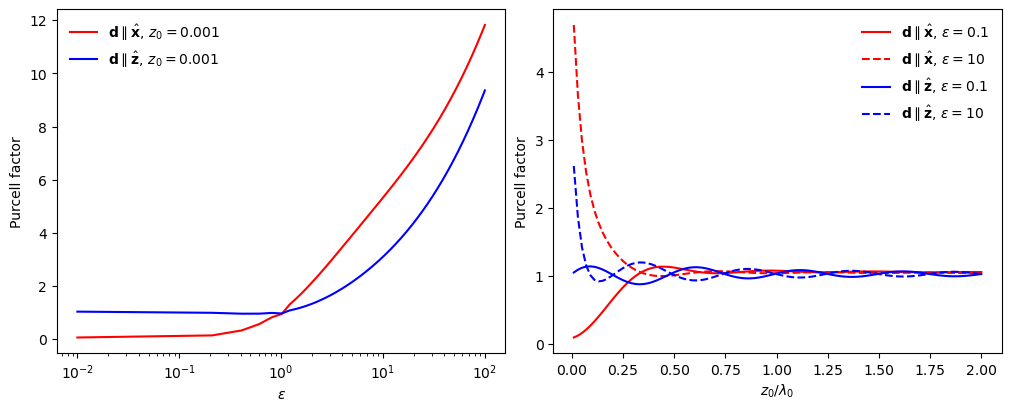

In [6]:
#plotting

fig, axes = plt.subplots(1,2, constrained_layout=True,figsize=(10, 4))

axes[0].set_xlabel(r'$\epsilon$')
axes[0].set_ylabel('Purcell factor')
axes[0].set_xscale('log')
axes[0].plot(epstab,fxxTab,color='red',label=r'${\bf d}\parallel \hat{\bf x},\,z_0=$'+str(z0))
axes[0].plot(epstab,fzzTab,color='blue',label=r'${\bf d}\parallel \hat{\bf z},\,z_0=$'+str(z0))
axes[0].legend(loc='upper left',fontsize=10,frameon=False)

axes[1].set_xlabel(r'$z_0/\lambda_0$')
axes[1].set_ylabel('Purcell factor')
axes[1].set_xscale('linear')
axes[1].plot(z0tab,fxxTab2[0],linestyle='-', color='red',label=r'${\bf d}\parallel \hat{\bf x},\,\epsilon=$'+str(epstab2[0]))
axes[1].plot(z0tab,fxxTab2[1],linestyle='--', color='red',label=r'${\bf d}\parallel \hat{\bf x},\,\epsilon=$'+str(epstab2[1]))
axes[1].plot(z0tab,fzzTab2[0],linestyle='-', color='blue',label=r'${\bf d}\parallel \hat{\bf z},\,\epsilon=$'+str(epstab2[0]))
axes[1].plot(z0tab,fzzTab2[1],linestyle='--', color='blue',label=r'${\bf d}\parallel \hat{\bf z},\,\epsilon=$'+str(epstab2[1]))
axes[1].legend(loc='upper right',fontsize=10,frameon=False)

In [ ]:
########### PART II ###########

In [156]:
#loading data from file
NFpx=np.loadtxt('decay_sphere/decay_sphere_done/double_Au_sphere_NF_px.dat')
NFpz=np.loadtxt('decay_sphere/decay_sphere_done/double_Au_sphere_NF_pz.dat')

NFpx_maps=np.loadtxt('decay_sphere/decay_sphere_done/double_Au_sphere_NF_px_map.dat')
NFpz_maps=np.loadtxt('decay_sphere/decay_sphere_done/double_Au_sphere_NF_pz_map.dat')

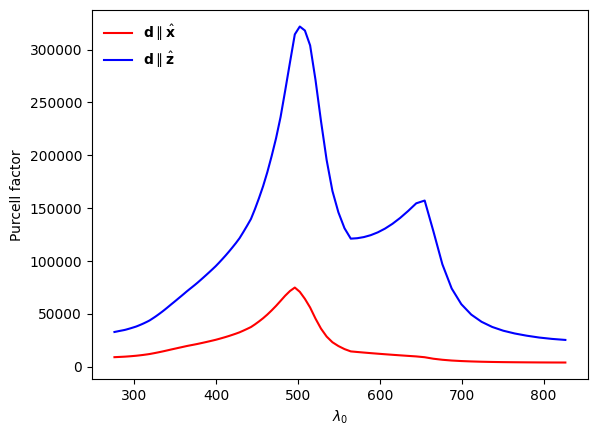

In [ ]:
wx=2*np.pi*cau*auev/nnm/NFpx[:,0]
PFx=(1+2*NFpx[:,4]/(4/3*(NFpx[:,0]/cau/auev)**3))
wz=2*np.pi*cau*auev/nnm/NFpz[:,0]
PFz=(1+2*NFpz[:,5]/(4/3*(NFpz[:,0]/cau/auev)**3))

plt.xlabel(r'$\lambda_0$')
plt.ylabel('Purcell factor')
plt.plot(wx,PFx,color='red',label=r'${\bf d}\parallel \hat{\bf x}$')
plt.plot(wz,PFz,color='blue',label=r'${\bf d}\parallel \hat{\bf z}$')
plt.legend(loc='upper left',fontsize=10,frameon=False)

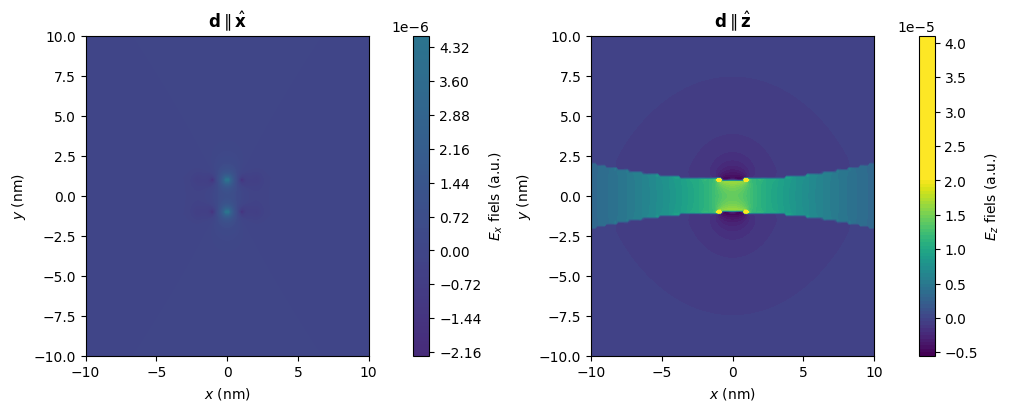

In [197]:

x = np.reshape(NFpx_maps[:,1], (150,150))
y = np.reshape(NFpx_maps[:,3], (150,150))
z = np.reshape(NFpx_maps[:,4], (150,150))


x1 = np.reshape(NFpz_maps[:,1], (150,150))
y1 = np.reshape(NFpz_maps[:,3], (150,150))
z1 = np.reshape(NFpz_maps[:,5], (150,150))


fig, axes = plt.subplots(1,2, constrained_layout=True,figsize=(10, 4))

minz, maxz = np.min(z1), 0.5*np.max(z1)

axes[0].set_xlabel(r'$x$ (nm)')
axes[0].set_ylabel(r'$y$ (nm)')
axes[0].set_title(r'${\bf d}\parallel \hat{\bf x}$')
c1=axes[0].contourf(x,y,z,vmin=minz,vmax=maxz,levels=100,cmap='viridis') #vmin and vmax set to the same values for both plots to allow comparison (it sets the limits of the color scale)
fig.colorbar(c1, ax=axes[0], label=r'$E_x$ fiels (a.u.)')

axes[1].set_xlabel(r'$x$ (nm)')
axes[1].set_ylabel(r'$y$ (nm)')
axes[1].set_title(r'${\bf d}\parallel \hat{\bf z}$')
c2=axes[1].contourf(x1,y1,z1,vmin=minz,vmax=maxz,levels=100,cmap='viridis')
fig.colorbar(c2, ax=axes[1], label=r'$E_z$ fiels (a.u.)')


In [214]:
########### PART III ###########

def ChState(alpha,m):
    alpha2=np.abs(alpha)**2
    return np.exp(-alpha2)*alpha2**m/math.factorial(m)

def ThState(th,m):
    return (1-np.exp(-th))*np.exp(-m*th)

def ThermalPe(gt,th,mmax):
    cc=np.array([ThState(th,m)*np.cos(2*np.sqrt(m+1)*gt) for m in range(mmax+1)])
    return 0.5-0.5*np.sum(cc) #Probability of finding the emitter in the ground state after a time gt

def CoherentPe(gt,alpha,mmax):
    cc=np.array([ChState(alpha,m)*np.cos(2*np.sqrt(m+1)*gt) for m in range(mmax+1)])
    return 0.5-0.5*np.sum(cc) #Probability of finding the emitter in the ground state after a time gt

In [262]:
#Time evolution of the probability of finding the emitter in the ground state for a thermal state and a coherent state

gtab=np.linspace(-80,80,4000)
mmax=20
alphatab=[0.1,1,1.5,3]
thtab=[1,0.5,0.1,0.01]

ChPeTab=[[CoherentPe(gt,alpha,mmax) for gt in gtab] for alpha in alphatab]
ThPeTab=[[ThermalPe(gt,th,mmax) for gt in gtab] for th in thtab]

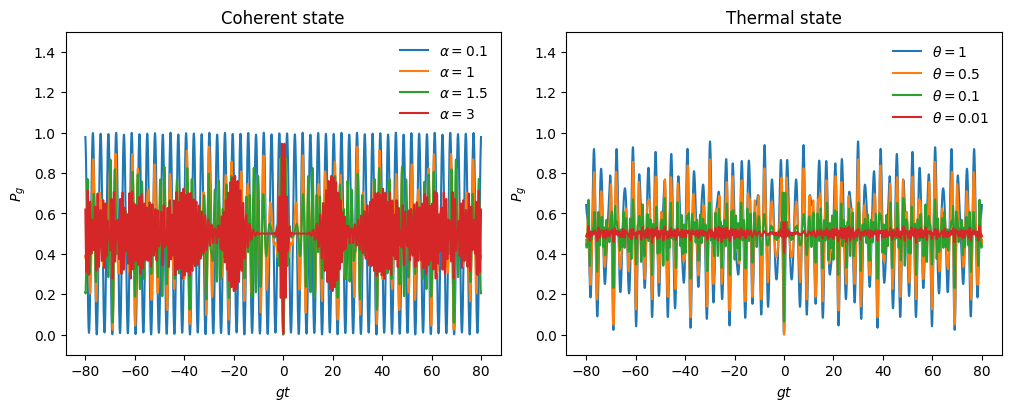

In [263]:
fig, axes = plt.subplots(1,2, constrained_layout=True,figsize=(10, 4))

axes[0].set_ylim(-0.1,1.5)
axes[0].set_xlabel(r'$gt$')
axes[0].set_ylabel(r'$P_g$')
axes[0].set_title('Coherent state')
for i in range(len(alphatab)):
    axes[0].plot(gtab,ChPeTab[i],label=r'$\alpha=$'+str(alphatab[i]))
axes[0].legend(loc='upper right',fontsize=10,frameon=False)

axes[1].set_ylim(-0.1,1.5)
axes[1].set_xlabel(r'$gt$')
axes[1].set_ylabel(r'$P_g$')
axes[1].set_title('Thermal state')
for i in range(len(thtab)):
    axes[1].plot(gtab,ThPeTab[i],label=r'$\theta=$'+str(thtab[i]))
axes[1].legend(loc='upper right',fontsize=10,frameon=False)

In [241]:
#Here we analyze the frequencies of the oscillations in the time evolution of P_g for the coherent state

#This function implements the integral Fourier Transform \int_-\infty^\infty dt f(t) exp(-i*w*t) (see the pdf relative to the practical 2)
def FFT(t,signal):
    n=len(signal)
    dt=t[1]-t[0]
    tmin=np.min(t)
    fft_result=np.fft.fft(signal)
    fft_result_shifted = np.fft.fftshift(fft_result)
    freqs=np.fft.fftfreq(n,dt)
    freqs_shifted = np.fft.fftshift(freqs)
    int_fft = dt*np.exp(-1j*tmin*freqs_shifted*2*np.pi)*fft_result_shifted
    return 2*np.pi*freqs_shifted, int_fft


In [ ]:
#Observing the quantized frequencies of the oscillations in the time evolution of P_g for the coherent state going as 2*sqrt(n+1)
wtab=[]
fttab=[]
for i in range(len(alphatab)):
    w,ft=FFT(gtab,ChPeTab[i])
    wtab.append(w)
    fttab.append(ft)

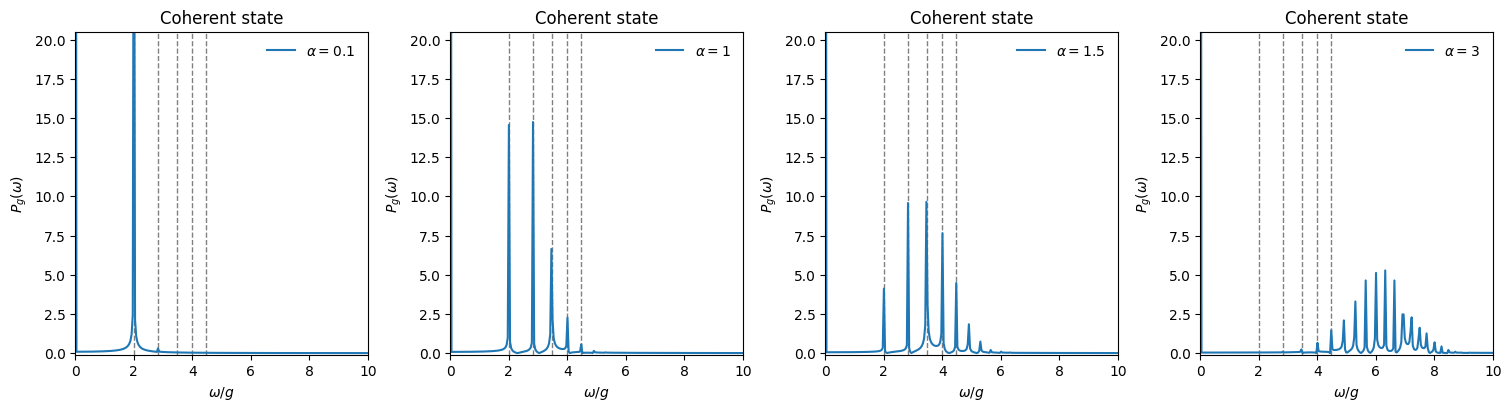

In [271]:
fig, axes = plt.subplots(1,len(alphatab), constrained_layout=True,figsize=(15, 4))

for i in range(len(alphatab)):
    for j in range(0,5):
        axes[i].axvline(x=2*np.sqrt(j+1), color='gray', linestyle='--', linewidth=1)
    axes[i].set_xlim(0,10)
    axes[i].set_ylim(-0.1,20.5)
    axes[i].set_xlabel(r'$\omega/g$')
    axes[i].set_ylabel(r'$P_g(\omega)$')
    axes[i].set_title('Coherent state')

    axes[i].plot(wtab[i],np.abs(fttab[i]),label=r'$\alpha=$'+str(alphatab[i]))
    axes[i].legend(loc='upper right',fontsize=10,frameon=False)